In [18]:
import os
dir = os.path.abspath('')  # directory of notebook
import sys
sys.path.append(os.path.join(dir, '..', '..'))  # package directory
from src.FoKL import FoKLRoutines
from src.FoKL.fokl_to_pyomo import fokl_to_pyomo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae
from scipy.interpolate import interp1d

In [19]:
data = pd.read_csv(os.path.join(dir, "data", "v11_training_data.csv"))

tvec = data["t"].values
Tabs = data["T"].values
u = data["u"].values

t0 = tvec[0]
tf = tvec[-1]
dt = (tf - t0) / (len(tvec) - 1)

Tamb = Tabs[0]
T = Tabs - Tamb

In [20]:
def smooth(x, window):
    """Apply centered average of size window."""
    x_smooth = np.zeros_like(x)
    w2 = int(np.floor(window / 2))
    w2p1 = w2 + 1

    # bleed in:
    for i in range(w2):
        x_smooth[i] = np.mean(x[:(i + w2p1)])

    # center:
    for i in range(w2, x_smooth.size - w2):
        x_smooth[i] = np.mean(x[(i - w2):(i + w2p1)])

    # bleed out:
    for i in range(-w2, 0):
        x_smooth[i] = np.mean(x[(i - w2)::])

    return x_smooth


def gradient_h4(x, h):
    """h is step size. Order of error is h^4."""
    dx = np.zeros_like(x)

    # bleed in:
    h2 = 2 * h
    dx[0] = (x[1] - x[0]) / h
    dx[1] = (x[2] - x[0]) / h2

    # center difference:
    h12 = 12 * h
    for i in range(2, x.shape[0] - 2):
        dx[i] = (x[i - 2] - 8 * x[i - 1] + 8 * x[i + 1] - x[i + 2]) / h12
    
    # bleed out:
    dx[-2] = (x[-1] - x[-3]) / h2
    dx[-1] = (x[-1] - x[-2]) / h

    return dx

In [21]:
T = smooth(T, 9)  # smooth
dT = gradient_h4(T, dt)  # derivative of smoothed

In [22]:
filename = os.path.join(dir, "models", "v11_synthetic.fokl")
GP = FoKLRoutines.load(filename)

In [23]:
def r(t):
    return np.interp(t, [0, 50, 150, 450, 550, 999], np.array([Tamb, Tamb, 60, 60, 35, 35]) - Tamb)

benchmark = np.loadtxt(os.path.join(dir, 'data', 'u1_benchmark_solution.csv'), delimiter=',')
benchmark = np.concatenate([np.array([t0, 0])[np.newaxis, :],
                            benchmark[1:107, :],
                            benchmark[130:218, :],
                            benchmark[243:354, :],
                            benchmark[370:-1, :]], axis=0)  # remove oscillations

def u_bmrk(t):
    return np.interp(t, benchmark[:, 0], benchmark[:, 1])

In [24]:
results_T = []
results_u = []

nfe = 100
solver = pyo.SolverFactory('ipopt')
solver.options['linear_solver'] = 'ma57'

for i in range(2):

    m = pyo.ConcreteModel("TCLab Heater with GP Model")
    m.t = dae.ContinuousSet(bounds=(0, 999))
    # m.T = pyo.Var(m.t, bounds = GP.minmax[0])
    m.T = pyo.Var(m.t)
    m.u = pyo.Var(m.t, bounds = GP.minmax[1])
    m.dT = dae.DerivativeVar(m.T, wrt=m.t)

    pyo.TransformationFactory('dae.finite_difference').apply_to(m, nfe=nfe)

    m.T[t0].fix(0.0)
    if i == 0:
        for t in m.t:
            m.u[t].fix(u_bmrk(t))  # fixed (i.e., benchmark)
    elif i == 1:
        for t in m.t:
            m.u[t] = u_bmrk(t)  # free (i.e., optimal)  
    
    fokl_to_pyomo(GP, [m.T, m.u], m.dT, m, m.t)

    @m.Integral(m.t)
    def ise(m, t):
        return (r(t) - m.T[t]) ** 2

    @m.Objective(sense=pyo.minimize)
    def obj(m):
        return m.ise
    
    solver.solve(m , tee=True)

    results_T.append(m.T[:]() + Tamb)
    results_u.append(m.u[:]())

Ipopt 3.13.2: linear_solver=ma57


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        compu

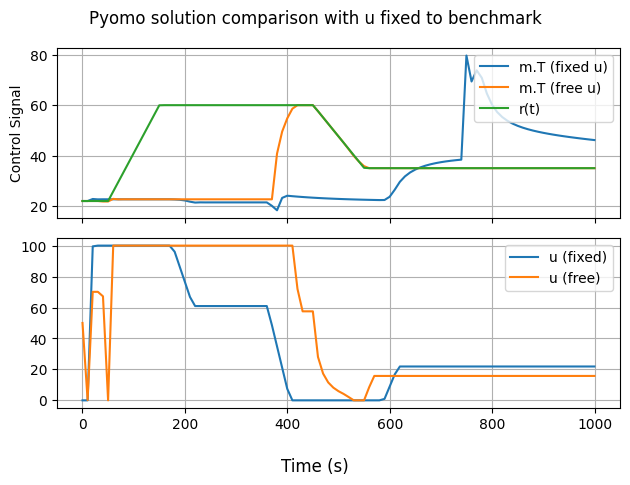

In [26]:
fig, axs = plt.subplots(2, sharex=True)
fig.suptitle("Pyomo solution comparison with u fixed to benchmark")
fig.supxlabel("Time (s)")

axs[0].plot(m.t, results_T[0], label="m.T (fixed u)")
axs[0].plot(m.t, results_T[1], label="m.T (free u)")
axs[0].plot(m.t, r(m.t) + Tamb, label="r(t)")
axs[0].set_ylabel("Temperature")

axs[1].plot(m.t, results_u[0], label="u (fixed)")
axs[1].plot(m.t, results_u[1], label="u (free)")
axs[0].set_ylabel("Control Signal")

for ax in axs:
    ax.legend()
    ax.grid()

fig.tight_layout()